# Deep Learning (Fall 2025) - Homework 4

---



*Developed by Hongtau Wu & Suzanna Sia*

This notebook contains all starter code for Homework 4. Please read the written assignment carefully to ensure you include all necessary outputs in your final report. Your final submission (a single zip file) should include this notebook (.ipynb file) and a PDF of this notebook with all cell outputs.

## Problem 1a)

### Imports

In [1]:
## External Libararies
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving DeepLearning_Fall2025_hw4_prob1_data.npy to DeepLearning_Fall2025_hw4_prob1_data.npy


### Data Loading

In [ ]:
## Spectify Path to Provided Data Here
DATA_PATH = 'DeepLearning_Fall2025_hw4_prob1_data.npy'

## Load Data and Check Dimensionality
data = np.load(DATA_PATH)
Y = data[:,2]
X = data[:,0:2]
print("Y:", Y.shape)
print("X:", X.shape)

## Polygon Boundaries
p = [[[500, 1000], [300, 800], [400, 600], [600, 600], [700, 800]],
     [[500, 600], [100, 400], [300, 200], [700, 200], [900, 400]]]
p = np.asarray(p)
p0 = p[0]
p1 = p[1]

Y: (60000,)
X: (60000, 2)


### Visualization Code

Do not touch any of the visualization code below.

In [ ]:
## Helper code for visualisation (No Need to Touch)
def visualize_polygons(p0, p1):
    """

    """
    fig, ax = plt.subplots()
    patches = []
    polygon1 = Polygon(p0, closed=True)
    polygon2 = Polygon(p1, closed=True)
    patches.append(polygon1)
    patches.append(polygon2)
    p = PatchCollection(patches, cmap=matplotlib.cm.jet, alpha=0.4)
    ax.add_collection(p)
    ax.autoscale_view()
    plt.show()

def visualize_datapoints(X, Y):
    """

    """
    assert(X.shape[0] == Y.shape[0])
    fig, ax = plt.subplots()
    npts = 60000
    col = np.where(Y[:npts]==1,'m','b')
    x1 = X[:npts][:,0]
    x2 = X[:npts][:,1]
    ax.scatter(x1, x2, s=0.5, c=col, zorder=1)
    plt.show()

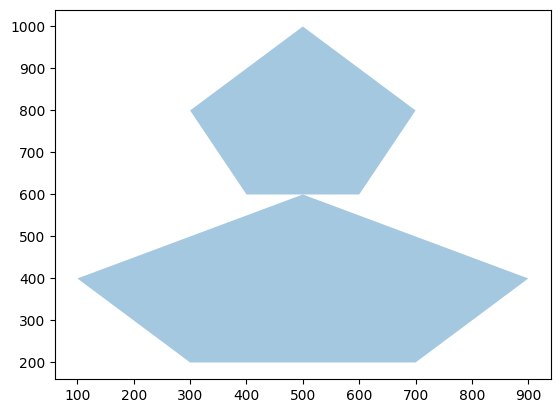

In [ ]:
visualize_polygons(p0,p1)

### Problem 1a)

Please fill in all code blocks marked with a #TODO.

In [ ]:
def threshold_activation1(x):
    """

    """
    y = np.copy(x)
    y[y <= 0] = 0
    y[y > 0] = 1
    return y


def and_gate(x):
    """
    #TODO: Implement an "and" gate
    """
    a = np.asarray(x).astype(int).reshape(-1)   # flatten to 1D
    return int(np.all(a == 1))


def or_gate(x):
    """
    #TODO: Implement an "or" gate
    """
    a = np.asarray(x).astype(int).reshape(-1)
    return int(np.any(a == 1))


def analytical_parameters(p0, p1):
    """

    """
    ## Dimensionality
    x_dim = 2
    class_num = 2
    hidden_unit_num = 10
    # First Layer Parameter
    W = np.zeros((hidden_unit_num, x_dim))
    b = np.zeros((hidden_unit_num, 1))
    for i in range(5):
        # First polygon
        x1 = p0[i, 0]
        y1 = p0[i, 1]
        x2 = p0[(i+1)%5, 0]
        y2 = p0[(i+1)%5, 1]
        W[i, :] = [y1 - y2, x2 - x1]
        b[i, :] = x1 * y2 - x2 * y1
        # Second polygon
        x1 = p1[i, 0]
        y1 = p1[i, 1]
        x2 = p1[(i+1)%5, 0]
        y2 = p1[(i+1)%5, 1]
        W[i + 5, :] = [y1 - y2, x2 - x1]
        b[i + 5, :] = x1 * y2 - x2 * y1
    return W,b

def predict_output_v1(X, W, b):
    """

    """
    predictions = []
    for idx in range(data.shape[0]):
        x = np.reshape(X[idx, :], (2, 1))
        # First layer
        first_layer_output = np.matmul(W, x) + b
        first_layer_output = threshold_activation1(first_layer_output)
        # Second layer
        first_polygon = first_layer_output[0:5, :]
        second_polygon = first_layer_output[5:10, :]
        first_gate_output = and_gate(first_polygon)
        second_gate_output = and_gate(second_polygon)
        # Output layer
        input_to_final_gate = [first_gate_output, second_gate_output]
        prediction = or_gate(input_to_final_gate)
        predictions.append(prediction)
    return predictions

def predict_output_v2(X, W, b):
    """
    #TODO: Update usage of the gates in this function
    """
    ## Cache of Predictions
    predictions = []
    ## Cycle Through Data Points
    for idx in range(data.shape[0]):
        x = np.reshape(X[idx, :], (2, 1))
        # First layer
        first_layer_output = np.matmul(W, x) + b
        first_layer_output = threshold_activation1(first_layer_output)
        # Second layer
        first_polygon = first_layer_output[0:5, :]
        first_gate_output = and_gate(first_polygon)
        # Output layer
        predictions.append(first_gate_output)
    return predictions

def calc_accuracy(true_y, pred_y):
    """

    """
    true_prediction_num = 0
    for i, py in enumerate(pred_y):
        if py == true_y[i]:
            true_prediction_num += 1
    accuracy = true_prediction_num / len(pred_y)
    print("Accuracy: ", accuracy)
    return accuracy

*Sanity check:* If you correctly implemented the 'and gate' and 'or gate', all points should be classified correctly when you make predictions using `predict_output_v1()`

Accuracy:  1.0


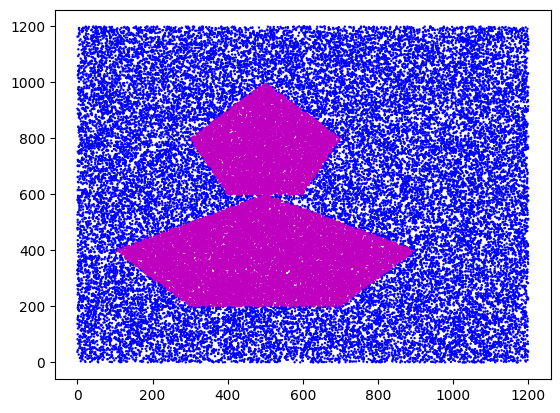

In [ ]:
## Load Our Parameters
W, b = analytical_parameters(p0, p1)

## Make Predictions
pred_Y = predict_output_v1(X, W, b)

## Compute Accuracy
acc = calc_accuracy(Y, pred_Y)
assert (acc == 1)

## Visualize Predictions
visualize_datapoints(X, np.array(pred_Y))

In the code above, change the gates in `predict_output_v2()` such that only the points in the top polygon are classified correctly. Visualize your result, report the accuracy of this model, and attach it to the submission.

To further clarify, you should **only** change the usage of the gating functions, not the code inside the gating function itself.

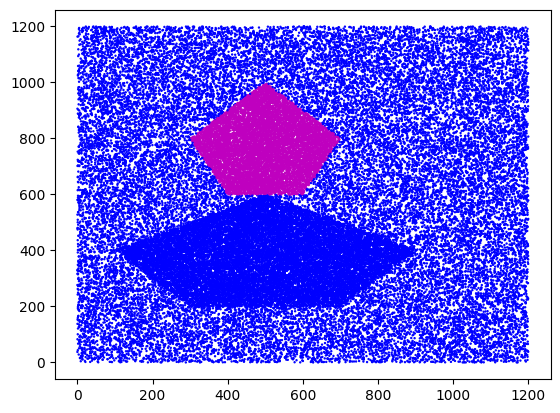

In [ ]:
## Load Our Parameters
W, b = analytical_parameters(p0, p1)

## Make Predictions
pred_Y = predict_output_v2(X, W, b)

## Visualize Predictions
visualize_datapoints(X, np.array(pred_Y))

## Problem 1b-d)

Complete problems 1b through 1d in the space below. Please use markdown to clearly distinguish your answers for each part. Include appropriate visualizations generated here in your final report.

###Problem 1b)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [ ]:
# Set random seeds for reproducibility
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True

In [ ]:
class MLP(nn.Module):
    def __init__(self, input_dim=2, hidden1_dim=10, hidden2_dim=2, output_dim=1):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden1_dim)
        self.fc2 = nn.Linear(hidden1_dim, hidden2_dim)
        self.fc3 = nn.Linear(hidden2_dim, output_dim)
        self.sigmoid = nn.Sigmoid()

        # Xavier initialization
        nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.xavier_uniform_(self.fc2.weight)
        nn.init.xavier_uniform_(self.fc3.weight)
        nn.init.zeros_(self.fc1.bias)
        nn.init.zeros_(self.fc2.bias)
        nn.init.zeros_(self.fc3.bias)

    def forward(self, x):
        x = self.sigmoid(self.fc1(x))
        x = self.sigmoid(self.fc2(x))
        x = self.sigmoid(self.fc3(x))
        return x

In [ ]:
def train_model(model, train_loader, test_loader, epochs=500, lr=0.1):
    criterion = nn.BCELoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    train_losses = []
    test_accuracies = []

    for epoch in range(epochs):
        # Training
        model.train()
        epoch_loss = 0
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        train_losses.append(epoch_loss / len(train_loader))

        # Testing
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for batch_x, batch_y in test_loader:
                outputs = model(batch_x)
                predicted = (outputs > 0.5).float()
                total += batch_y.size(0)
                correct += (predicted == batch_y).sum().item()

        test_accuracy = correct / total
        test_accuracies.append(test_accuracy)

        if epoch % 50 == 0:
            print(f'Epoch [{epoch}/{epochs}], Loss: {epoch_loss/len(train_loader):.4f}, Test Acc: {test_accuracy:.4f}')

    return train_losses, test_accuracies

In [ ]:
def evaluate_model(model, X, y):
    model.eval()
    with torch.no_grad():
        outputs = model(X)
        predicted = (outputs > 0.5).float()
        accuracy = (predicted == y).float().mean()
    return accuracy.item()

In [ ]:
def plot_results(train_losses, test_accuracies, seed):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(train_losses)
    ax1.set_title(f'Training Loss (Seed {seed})')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.grid(True)

    ax2.plot(test_accuracies)
    ax2.set_title(f'Test Accuracy (Seed {seed})')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
# Normalize the data
data_mean = X.mean(axis=0)
data_std = X.std(axis=0)
X_normalized = (X - data_mean) / data_std

# Split data (first 50000 for training, last 10000 for testing)
train_data = X_normalized[:50000]
train_labels = Y[:50000]
test_data = X_normalized[50000:]
test_labels = Y[50000:]

# Convert to PyTorch tensors and reshape labels to (n, 1)
train_data_tensor = torch.FloatTensor(train_data)
train_labels_tensor = torch.FloatTensor(train_labels).reshape(-1, 1)
test_data_tensor = torch.FloatTensor(test_data)
test_labels_tensor = torch.FloatTensor(test_labels).reshape(-1, 1)

# Create datasets and dataloaders
train_dataset = TensorDataset(train_data_tensor, train_labels_tensor)
test_dataset = TensorDataset(test_data_tensor, test_labels_tensor)


Training with seed 7

Epoch [0/500], Loss: 0.6906, Test Acc: 0.6546
Epoch [50/500], Loss: 0.5065, Test Acc: 0.7332
Epoch [100/500], Loss: 0.5019, Test Acc: 0.7379
Epoch [150/500], Loss: 0.1963, Test Acc: 0.9478
Epoch [200/500], Loss: 0.0770, Test Acc: 0.9785
Epoch [250/500], Loss: 0.0428, Test Acc: 0.9878
Epoch [300/500], Loss: 0.0349, Test Acc: 0.9892
Epoch [350/500], Loss: 0.0307, Test Acc: 0.9900
Epoch [400/500], Loss: 0.0277, Test Acc: 0.9912
Epoch [450/500], Loss: 0.0257, Test Acc: 0.9926
Final Train Accuracy: 0.9920
Final Test Accuracy: 0.9928


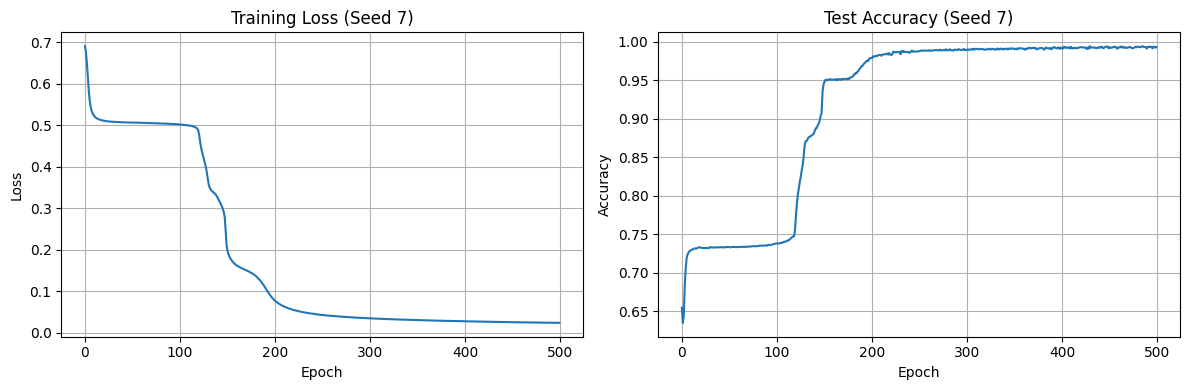

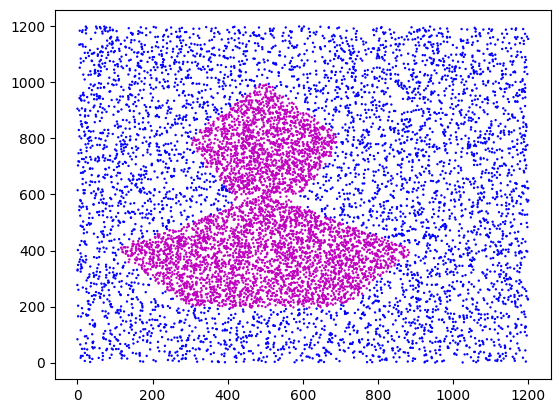


Training with seed 123

Epoch [0/500], Loss: 0.6882, Test Acc: 0.6305
Epoch [50/500], Loss: 0.1604, Test Acc: 0.9539
Epoch [100/500], Loss: 0.1172, Test Acc: 0.9660
Epoch [150/500], Loss: 0.0497, Test Acc: 0.9844
Epoch [200/500], Loss: 0.0373, Test Acc: 0.9896
Epoch [250/500], Loss: 0.0321, Test Acc: 0.9893
Epoch [300/500], Loss: 0.0289, Test Acc: 0.9912
Epoch [350/500], Loss: 0.0269, Test Acc: 0.9921
Epoch [400/500], Loss: 0.0252, Test Acc: 0.9929
Epoch [450/500], Loss: 0.0237, Test Acc: 0.9924
Final Train Accuracy: 0.9915
Final Test Accuracy: 0.9929


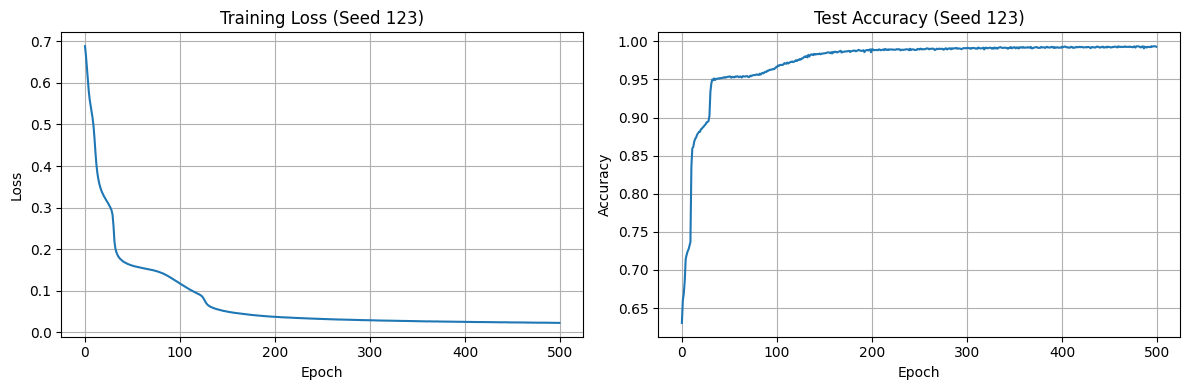

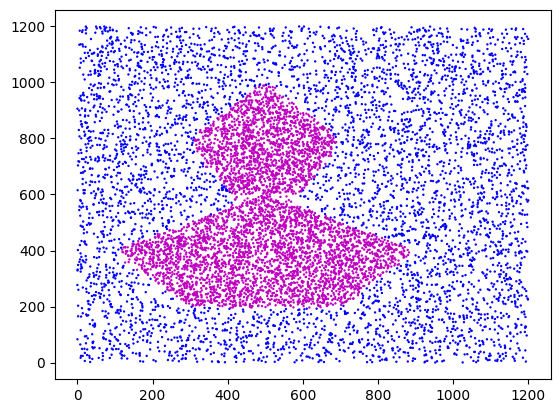


Training with seed 456

Epoch [0/500], Loss: 0.6945, Test Acc: 0.6895
Epoch [50/500], Loss: 0.1628, Test Acc: 0.9522
Epoch [100/500], Loss: 0.1352, Test Acc: 0.9591
Epoch [150/500], Loss: 0.0603, Test Acc: 0.9840
Epoch [200/500], Loss: 0.0470, Test Acc: 0.9867
Epoch [250/500], Loss: 0.0418, Test Acc: 0.9868
Epoch [300/500], Loss: 0.0391, Test Acc: 0.9890
Epoch [350/500], Loss: 0.0371, Test Acc: 0.9892
Epoch [400/500], Loss: 0.0358, Test Acc: 0.9894
Epoch [450/500], Loss: 0.0346, Test Acc: 0.9900
Final Train Accuracy: 0.9896
Final Test Accuracy: 0.9905


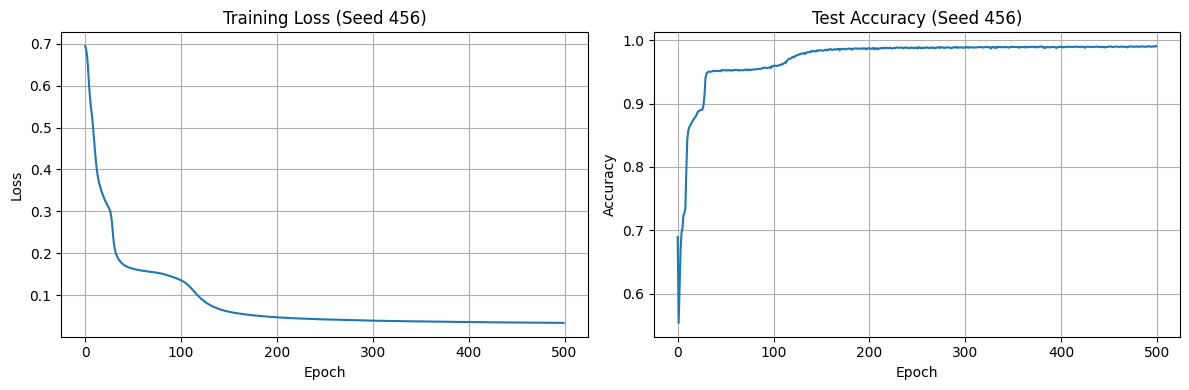

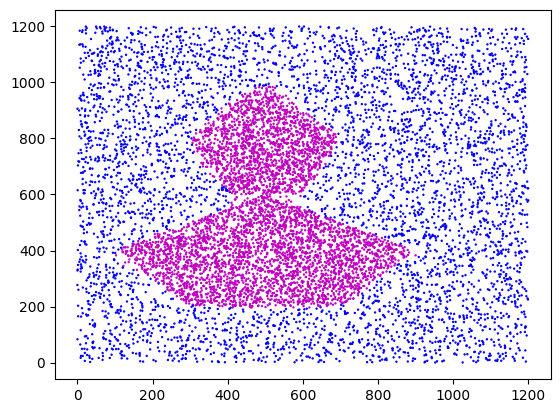


Training with seed 789

Epoch [0/500], Loss: 0.6896, Test Acc: 0.5480
Epoch [50/500], Loss: 0.1788, Test Acc: 0.9502
Epoch [100/500], Loss: 0.1470, Test Acc: 0.9531
Epoch [150/500], Loss: 0.0749, Test Acc: 0.9778
Epoch [200/500], Loss: 0.0515, Test Acc: 0.9827
Epoch [250/500], Loss: 0.0456, Test Acc: 0.9848
Epoch [300/500], Loss: 0.0421, Test Acc: 0.9856
Epoch [350/500], Loss: 0.0383, Test Acc: 0.9868
Epoch [400/500], Loss: 0.0344, Test Acc: 0.9878
Epoch [450/500], Loss: 0.0314, Test Acc: 0.9902
Final Train Accuracy: 0.9894
Final Test Accuracy: 0.9907


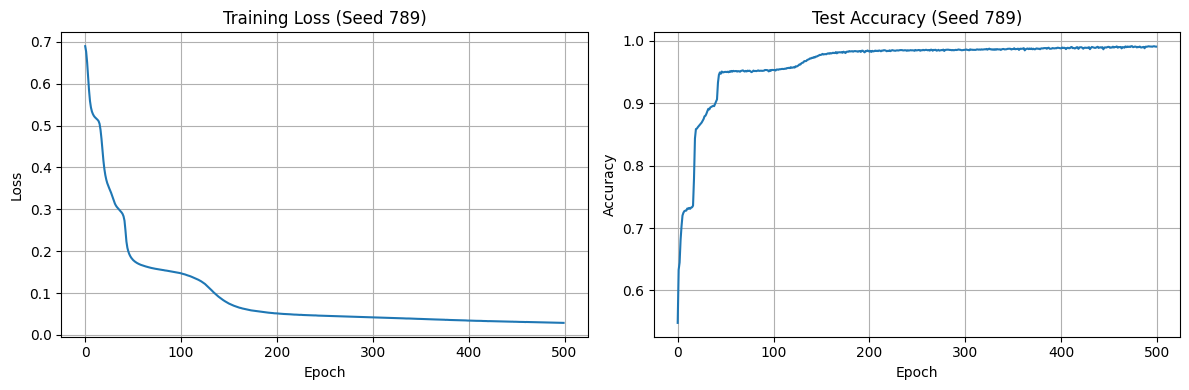

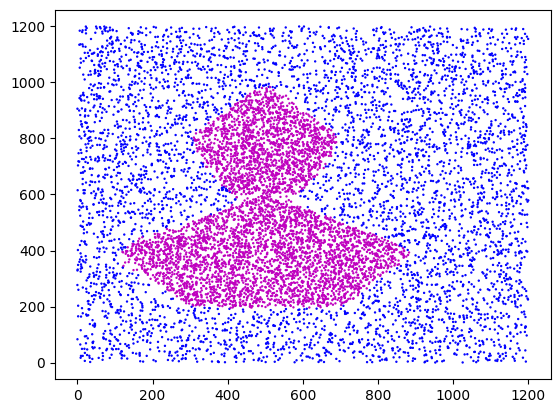


Training with seed 999

Epoch [0/500], Loss: 0.6775, Test Acc: 0.6342
Epoch [50/500], Loss: 0.2678, Test Acc: 0.9181
Epoch [100/500], Loss: 0.1491, Test Acc: 0.9546
Epoch [150/500], Loss: 0.0829, Test Acc: 0.9736
Epoch [200/500], Loss: 0.0486, Test Acc: 0.9876
Epoch [250/500], Loss: 0.0415, Test Acc: 0.9889
Epoch [300/500], Loss: 0.0379, Test Acc: 0.9898
Epoch [350/500], Loss: 0.0352, Test Acc: 0.9906
Epoch [400/500], Loss: 0.0333, Test Acc: 0.9900
Epoch [450/500], Loss: 0.0318, Test Acc: 0.9920
Final Train Accuracy: 0.9915
Final Test Accuracy: 0.9924


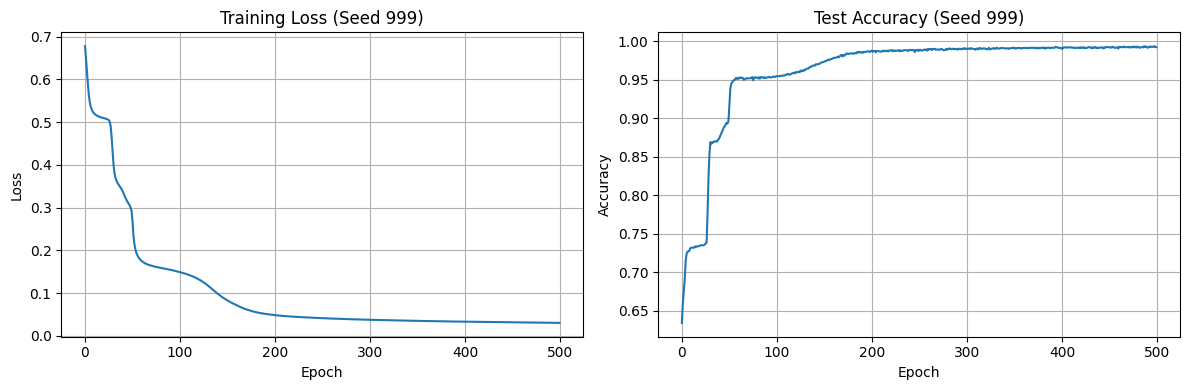

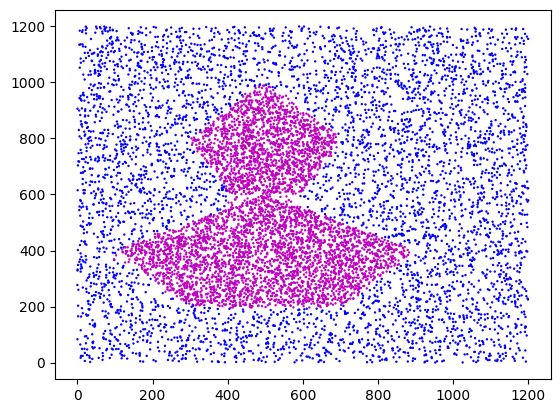


Summary Statistics
Train Accuracies: ['0.9920', '0.9915', '0.9896', '0.9894', '0.9915']
Test Accuracies: ['0.9928', '0.9929', '0.9905', '0.9907', '0.9924']
Mean Train Accuracy: 0.9908 ± 0.0011
Mean Test Accuracy: 0.9919 ± 0.0010


In [ ]:
# Hyperparameters
batch_size = 128
learning_rate = 0.1
epochs = 500
seeds = [7, 123, 456, 789, 999]

train_accuracies = []
test_accuracies = []

for i, seed in enumerate(seeds):
    print(f"\nTraining with seed {seed}\n")
    set_seed(seed)

    # Create model and dataloaders
    model = MLP()
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # Train model
    train_losses, test_accs = train_model(model, train_loader, test_loader, epochs, learning_rate)

    # Final evaluation
    train_acc = evaluate_model(model, train_data_tensor, train_labels_tensor)
    test_acc = evaluate_model(model, test_data_tensor, test_labels_tensor)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(f"Final Train Accuracy: {train_acc:.4f}")
    print(f"Final Test Accuracy: {test_acc:.4f}")

    # Plot training curves
    plot_results(train_losses, test_accs, seed)

    # Visualize predictions
    model.eval()
    with torch.no_grad():
        # Get predictions for test set (last 10000 points)
        test_predictions = model(test_data_tensor)
        test_predictions = (test_predictions > 0.5).float().numpy().flatten()
    visualize_datapoints(X[50000:], test_predictions)

# Print summary statistics
print("\nSummary Statistics")
print(f"Train Accuracies: {[f'{acc:.4f}' for acc in train_accuracies]}")
print(f"Test Accuracies: {[f'{acc:.4f}' for acc in test_accuracies]}")
print(f"Mean Train Accuracy: {np.mean(train_accuracies):.4f} ± {np.std(train_accuracies):.4f}")
print(f"Mean Test Accuracy: {np.mean(test_accuracies):.4f} ± {np.std(test_accuracies):.4f}")


### Problem 1c)

In [ ]:
class FlexibleMLP(nn.Module):
    def __init__(self, input_dim=2, hidden_dims=[64, 32, 16], output_dim=1):
        """
        Flexible MLP that can vary in both depth and width
        hidden_dims: list of integers specifying the width of each hidden layer
        """
        super(FlexibleMLP, self).__init__()

        # Create layers dynamically based on hidden_dims
        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.Sigmoid())
            prev_dim = hidden_dim

        # Output layer
        layers.append(nn.Linear(prev_dim, output_dim))
        layers.append(nn.Sigmoid())

        self.network = nn.Sequential(*layers)

        # Xavier initialization for all linear layers
        self._initialize_weights()

    def _initialize_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)

    def forward(self, x):
        return self.network(x)

Testing Architecture: Increased Width
Hidden Dimensions: [128, 64]

Training with seed 7
Epoch [0/500], Loss: 0.6875, Test Acc: 0.4977
Epoch [50/500], Loss: 0.1574, Test Acc: 0.9525
Epoch [100/500], Loss: 0.0878, Test Acc: 0.9760
Epoch [150/500], Loss: 0.0636, Test Acc: 0.9815
Epoch [200/500], Loss: 0.0485, Test Acc: 0.9870
Epoch [250/500], Loss: 0.0386, Test Acc: 0.9897
Epoch [300/500], Loss: 0.0329, Test Acc: 0.9912
Epoch [350/500], Loss: 0.0291, Test Acc: 0.9904
Epoch [400/500], Loss: 0.0264, Test Acc: 0.9926
Epoch [450/500], Loss: 0.0240, Test Acc: 0.9924
Final Train Accuracy: 0.9925
Final Test Accuracy: 0.9927


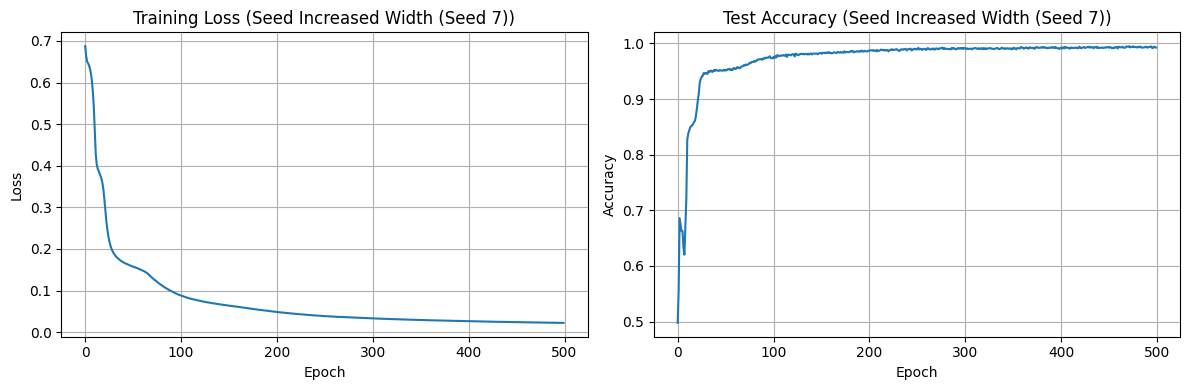

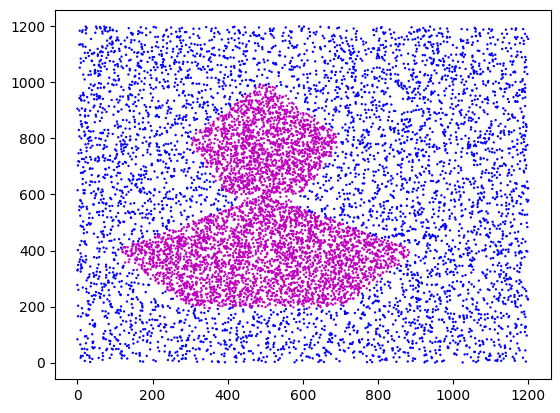


Training with seed 123
Epoch [0/500], Loss: 0.6849, Test Acc: 0.6925
Epoch [50/500], Loss: 0.1571, Test Acc: 0.9518
Epoch [100/500], Loss: 0.0824, Test Acc: 0.9777
Epoch [150/500], Loss: 0.0584, Test Acc: 0.9835
Epoch [200/500], Loss: 0.0484, Test Acc: 0.9857
Epoch [250/500], Loss: 0.0412, Test Acc: 0.9874
Epoch [300/500], Loss: 0.0354, Test Acc: 0.9915
Epoch [350/500], Loss: 0.0320, Test Acc: 0.9915
Epoch [400/500], Loss: 0.0294, Test Acc: 0.9901
Epoch [450/500], Loss: 0.0275, Test Acc: 0.9929
Final Train Accuracy: 0.9927
Final Test Accuracy: 0.9933


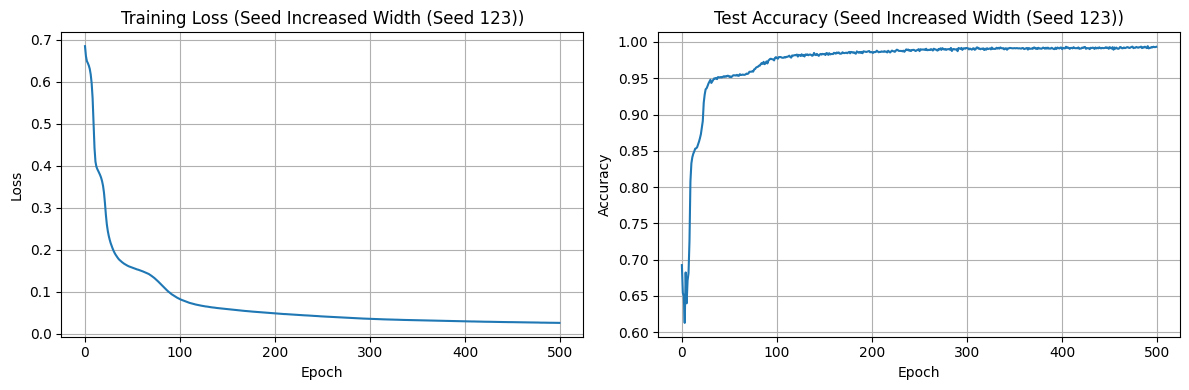

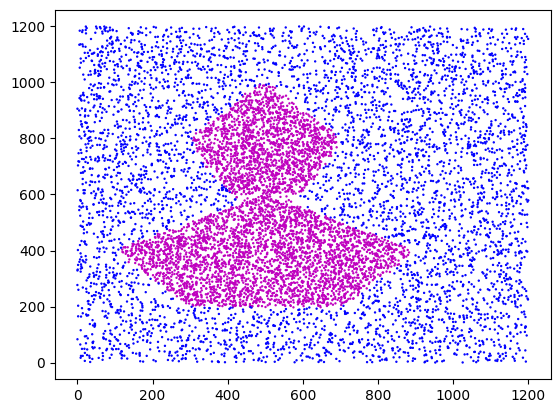


Training with seed 456
Epoch [0/500], Loss: 0.6862, Test Acc: 0.5472
Epoch [50/500], Loss: 0.1222, Test Acc: 0.9632
Epoch [100/500], Loss: 0.0728, Test Acc: 0.9781
Epoch [150/500], Loss: 0.0550, Test Acc: 0.9845
Epoch [200/500], Loss: 0.0419, Test Acc: 0.9869
Epoch [250/500], Loss: 0.0355, Test Acc: 0.9882
Epoch [300/500], Loss: 0.0312, Test Acc: 0.9923
Epoch [350/500], Loss: 0.0282, Test Acc: 0.9930
Epoch [400/500], Loss: 0.0258, Test Acc: 0.9936
Epoch [450/500], Loss: 0.0240, Test Acc: 0.9927
Final Train Accuracy: 0.9930
Final Test Accuracy: 0.9939


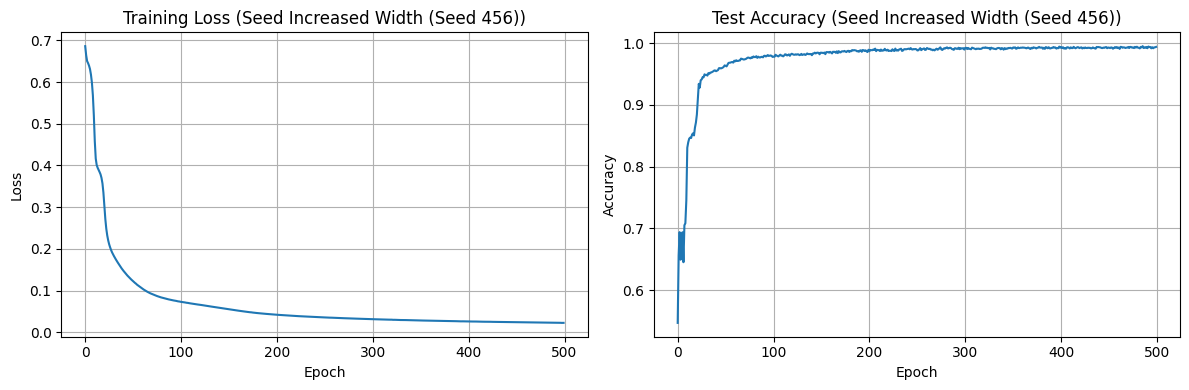

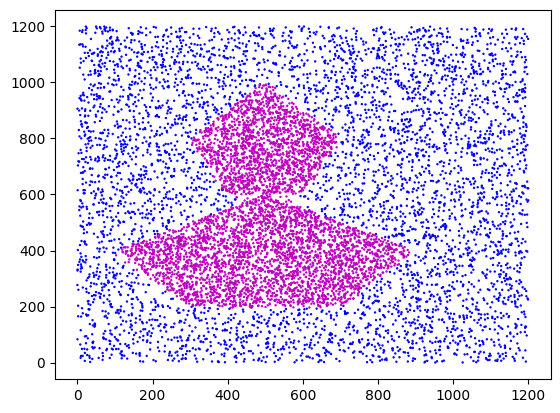


Training with seed 789
Epoch [0/500], Loss: 0.6887, Test Acc: 0.6198
Epoch [50/500], Loss: 0.1182, Test Acc: 0.9662
Epoch [100/500], Loss: 0.0607, Test Acc: 0.9827
Epoch [150/500], Loss: 0.0461, Test Acc: 0.9859
Epoch [200/500], Loss: 0.0397, Test Acc: 0.9901
Epoch [250/500], Loss: 0.0353, Test Acc: 0.9894
Epoch [300/500], Loss: 0.0321, Test Acc: 0.9899
Epoch [350/500], Loss: 0.0294, Test Acc: 0.9917
Epoch [400/500], Loss: 0.0272, Test Acc: 0.9940
Epoch [450/500], Loss: 0.0254, Test Acc: 0.9917
Final Train Accuracy: 0.9934
Final Test Accuracy: 0.9942


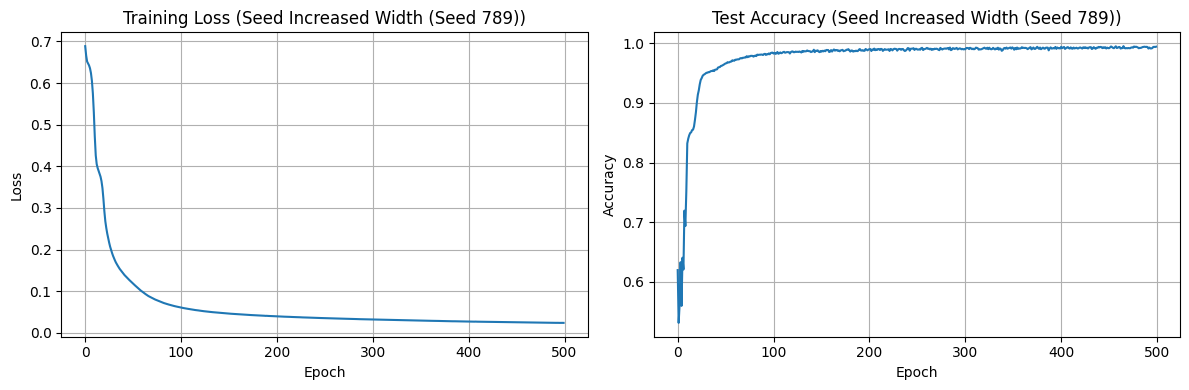

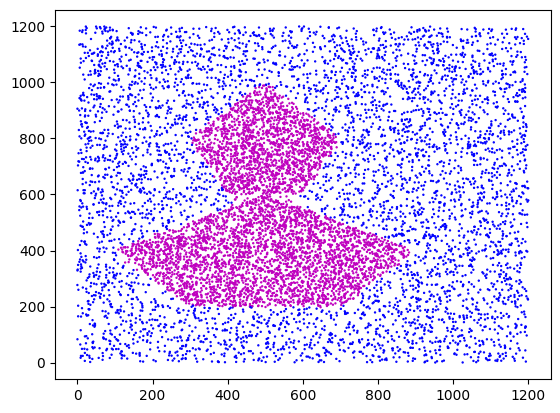


Training with seed 999
Epoch [0/500], Loss: 0.6871, Test Acc: 0.6468
Epoch [50/500], Loss: 0.1381, Test Acc: 0.9579
Epoch [100/500], Loss: 0.0689, Test Acc: 0.9799
Epoch [150/500], Loss: 0.0499, Test Acc: 0.9841
Epoch [200/500], Loss: 0.0386, Test Acc: 0.9877
Epoch [250/500], Loss: 0.0335, Test Acc: 0.9903
Epoch [300/500], Loss: 0.0302, Test Acc: 0.9909
Epoch [350/500], Loss: 0.0279, Test Acc: 0.9919
Epoch [400/500], Loss: 0.0261, Test Acc: 0.9937
Epoch [450/500], Loss: 0.0245, Test Acc: 0.9927
Final Train Accuracy: 0.9929
Final Test Accuracy: 0.9934


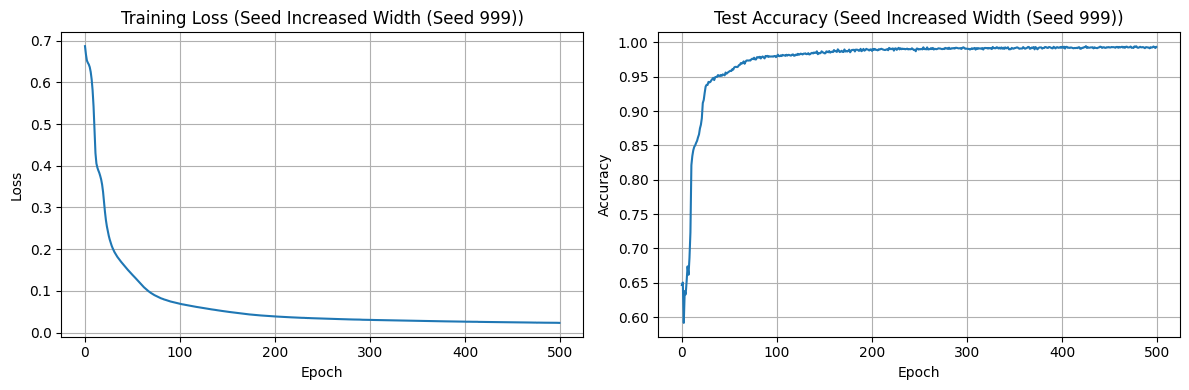

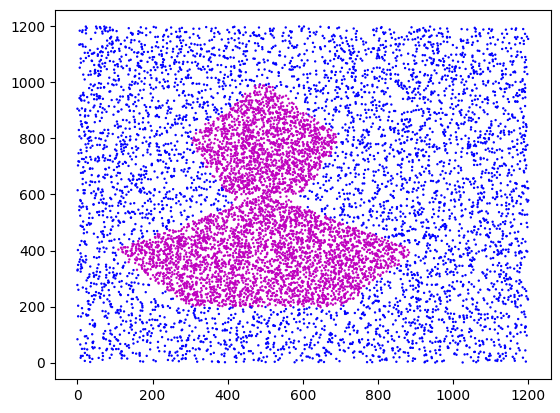


Increased Width Summary:
Train Accuracies: ['0.9925', '0.9927', '0.9930', '0.9934', '0.9929']
Test Accuracies: ['0.9927', '0.9933', '0.9939', '0.9942', '0.9934']
Mean Train Accuracy: 0.9929 ± 0.0003
Mean Test Accuracy: 0.9935 ± 0.0005
Testing Architecture: Increased Depth
Hidden Dimensions: [32, 16, 8, 4]

Training with seed 7
Epoch [0/500], Loss: 0.6935, Test Acc: 0.5023
Epoch [50/500], Loss: 0.5062, Test Acc: 0.7333
Epoch [100/500], Loss: 0.1875, Test Acc: 0.9426
Epoch [150/500], Loss: 0.0590, Test Acc: 0.9785
Epoch [200/500], Loss: 0.0303, Test Acc: 0.9906
Epoch [250/500], Loss: 0.0244, Test Acc: 0.9924
Epoch [300/500], Loss: 0.0230, Test Acc: 0.9924
Epoch [350/500], Loss: 0.0213, Test Acc: 0.9875
Epoch [400/500], Loss: 0.0200, Test Acc: 0.9922
Epoch [450/500], Loss: 0.0190, Test Acc: 0.9911
Final Train Accuracy: 0.9923
Final Test Accuracy: 0.9922


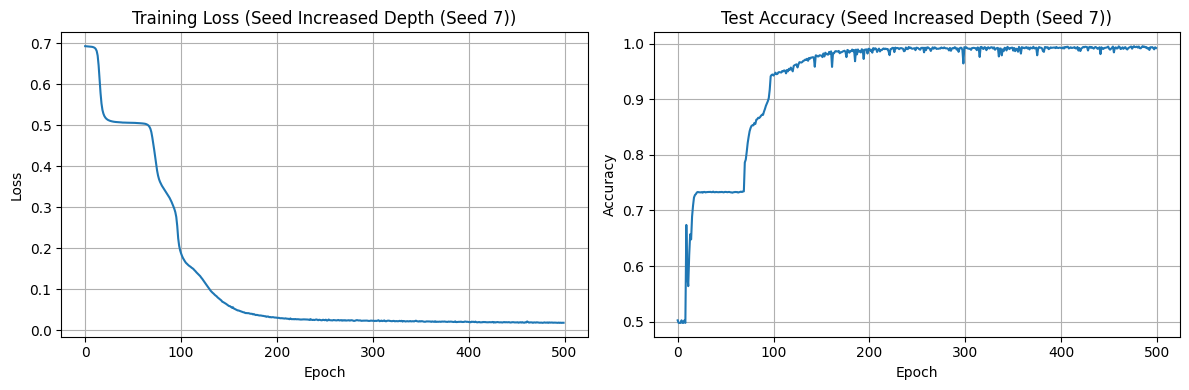

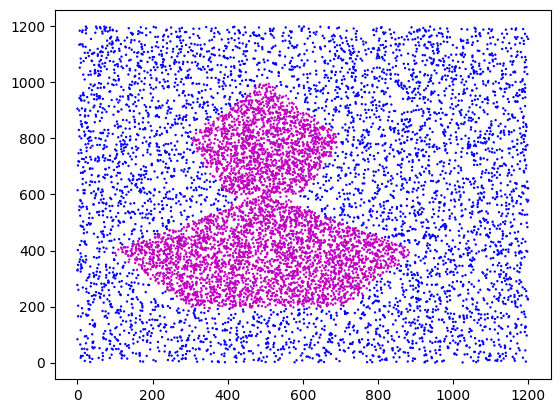


Training with seed 123
Epoch [0/500], Loss: 0.6937, Test Acc: 0.5023
Epoch [50/500], Loss: 0.3552, Test Acc: 0.8594
Epoch [100/500], Loss: 0.1171, Test Acc: 0.9640
Epoch [150/500], Loss: 0.0556, Test Acc: 0.9859
Epoch [200/500], Loss: 0.0337, Test Acc: 0.9903
Epoch [250/500], Loss: 0.0296, Test Acc: 0.9921
Epoch [300/500], Loss: 0.0243, Test Acc: 0.9896
Epoch [350/500], Loss: 0.0234, Test Acc: 0.9911
Epoch [400/500], Loss: 0.0203, Test Acc: 0.9941
Epoch [450/500], Loss: 0.0185, Test Acc: 0.9917
Final Train Accuracy: 0.9938
Final Test Accuracy: 0.9948


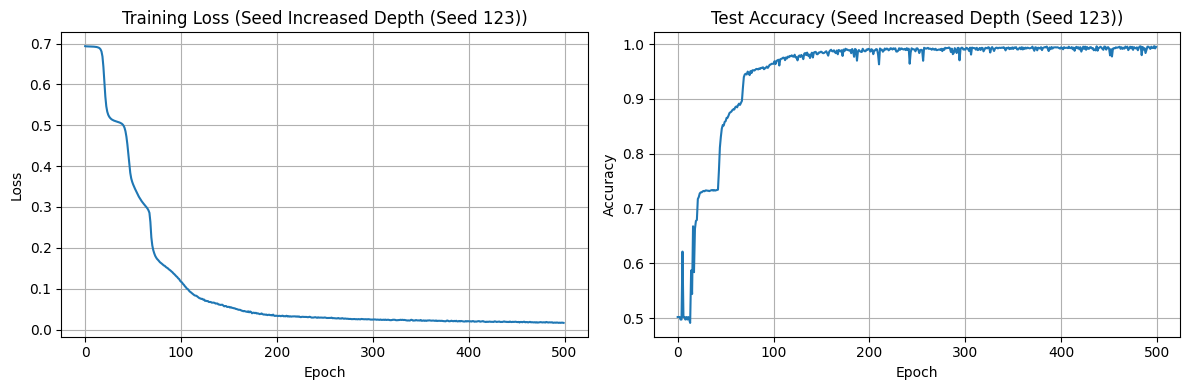

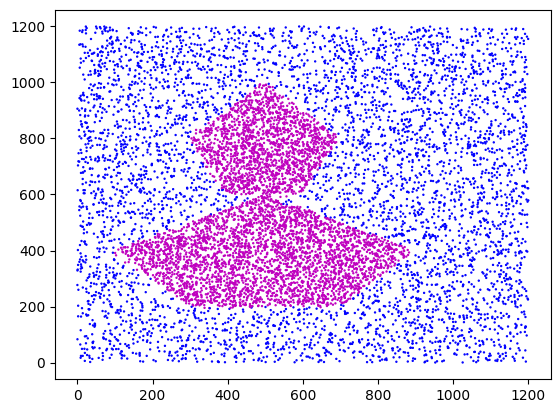


Training with seed 456
Epoch [0/500], Loss: 0.6933, Test Acc: 0.4977
Epoch [50/500], Loss: 0.5066, Test Acc: 0.7326
Epoch [100/500], Loss: 0.5061, Test Acc: 0.7326
Epoch [150/500], Loss: 0.5056, Test Acc: 0.7327
Epoch [200/500], Loss: 0.5042, Test Acc: 0.7336
Epoch [250/500], Loss: 0.1606, Test Acc: 0.9534
Epoch [300/500], Loss: 0.0587, Test Acc: 0.9835
Epoch [350/500], Loss: 0.0428, Test Acc: 0.9864
Epoch [400/500], Loss: 0.0362, Test Acc: 0.9866
Epoch [450/500], Loss: 0.0298, Test Acc: 0.9874
Final Train Accuracy: 0.9833
Final Test Accuracy: 0.9853


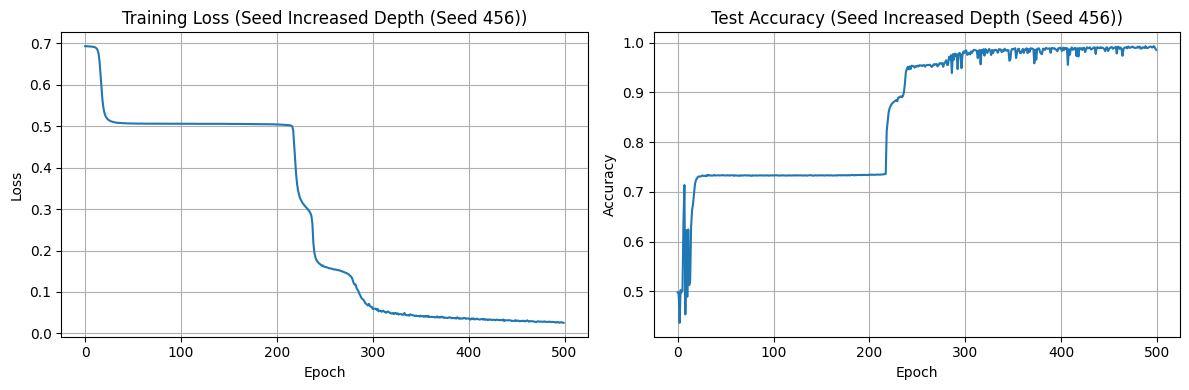

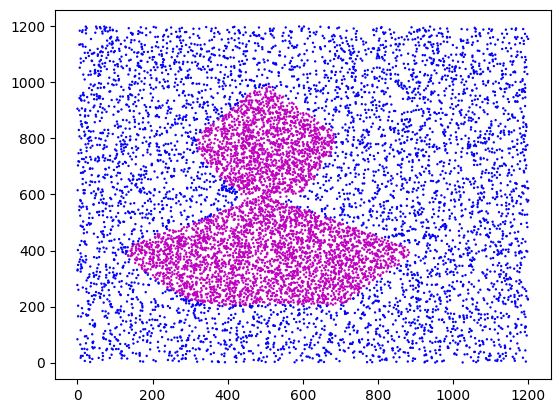


Training with seed 789
Epoch [0/500], Loss: 0.6950, Test Acc: 0.4977
Epoch [50/500], Loss: 0.3374, Test Acc: 0.8717
Epoch [100/500], Loss: 0.0574, Test Acc: 0.9770
Epoch [150/500], Loss: 0.0367, Test Acc: 0.9815
Epoch [200/500], Loss: 0.0286, Test Acc: 0.9911
Epoch [250/500], Loss: 0.0241, Test Acc: 0.9914
Epoch [300/500], Loss: 0.0218, Test Acc: 0.9909
Epoch [350/500], Loss: 0.0203, Test Acc: 0.9932
Epoch [400/500], Loss: 0.0184, Test Acc: 0.9949
Epoch [450/500], Loss: 0.0166, Test Acc: 0.9949
Final Train Accuracy: 0.9947
Final Test Accuracy: 0.9955


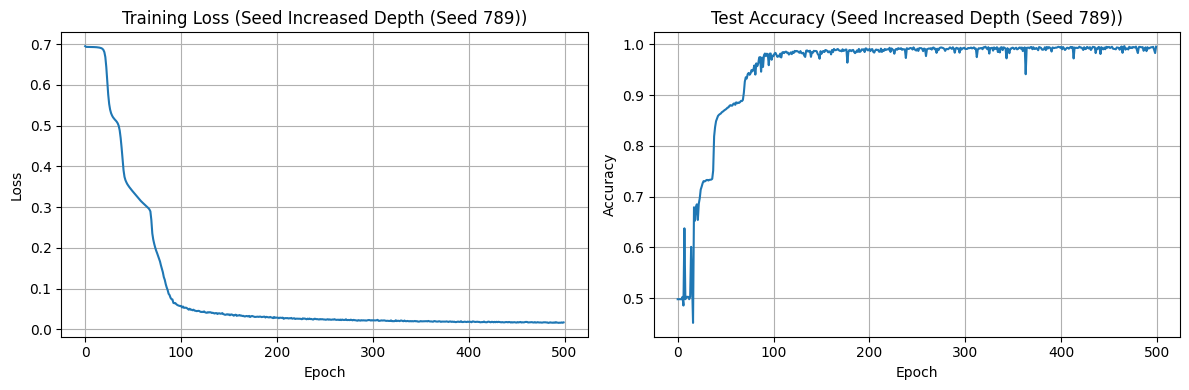

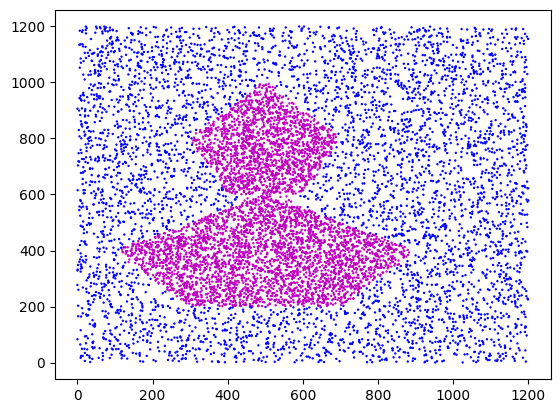


Training with seed 999
Epoch [0/500], Loss: 0.6971, Test Acc: 0.5023
Epoch [50/500], Loss: 0.3245, Test Acc: 0.8774
Epoch [100/500], Loss: 0.1054, Test Acc: 0.9697
Epoch [150/500], Loss: 0.0455, Test Acc: 0.9777
Epoch [200/500], Loss: 0.0301, Test Acc: 0.9909
Epoch [250/500], Loss: 0.0242, Test Acc: 0.9919
Epoch [300/500], Loss: 0.0214, Test Acc: 0.9916
Epoch [350/500], Loss: 0.0190, Test Acc: 0.9903
Epoch [400/500], Loss: 0.0181, Test Acc: 0.9953
Epoch [450/500], Loss: 0.0173, Test Acc: 0.9948
Final Train Accuracy: 0.9936
Final Test Accuracy: 0.9944


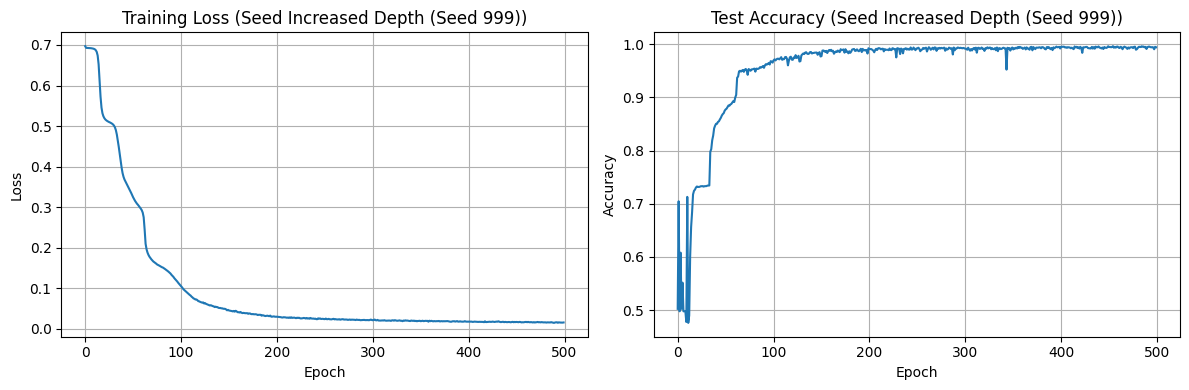

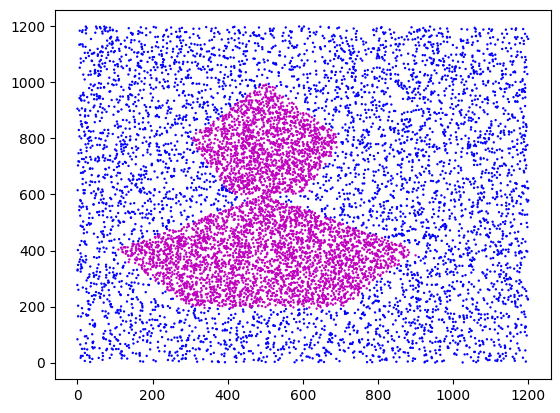


Increased Depth Summary:
Train Accuracies: ['0.9923', '0.9938', '0.9833', '0.9947', '0.9936']
Test Accuracies: ['0.9922', '0.9948', '0.9853', '0.9955', '0.9944']
Mean Train Accuracy: 0.9915 ± 0.0042
Mean Test Accuracy: 0.9924 ± 0.0037
Testing Architecture: Large Capacity
Hidden Dimensions: [256, 128, 64, 32]

Training with seed 7
Epoch [0/500], Loss: 0.6944, Test Acc: 0.4977
Epoch [50/500], Loss: 0.1934, Test Acc: 0.9381
Epoch [100/500], Loss: 0.0443, Test Acc: 0.9837
Epoch [150/500], Loss: 0.0278, Test Acc: 0.9889
Epoch [200/500], Loss: 0.0234, Test Acc: 0.9894
Epoch [250/500], Loss: 0.0201, Test Acc: 0.9925
Epoch [300/500], Loss: 0.0201, Test Acc: 0.9911
Epoch [350/500], Loss: 0.0192, Test Acc: 0.9937
Epoch [400/500], Loss: 0.0166, Test Acc: 0.9837
Epoch [450/500], Loss: 0.0158, Test Acc: 0.9934
Final Train Accuracy: 0.9927
Final Test Accuracy: 0.9932


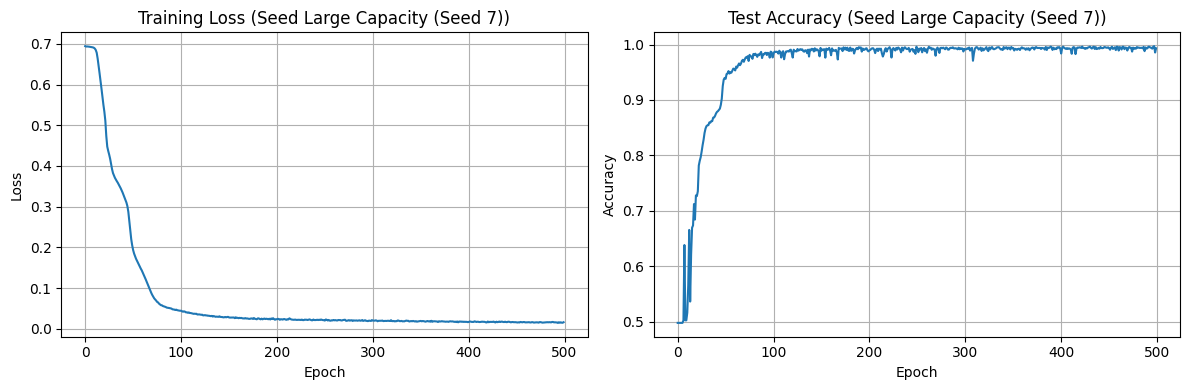

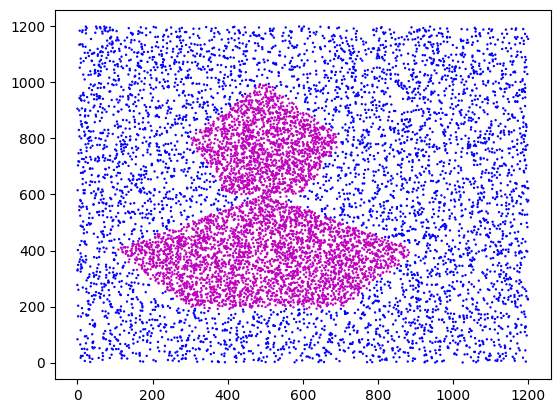


Training with seed 123
Epoch [0/500], Loss: 0.6938, Test Acc: 0.4977
Epoch [50/500], Loss: 0.1792, Test Acc: 0.9392
Epoch [100/500], Loss: 0.0422, Test Acc: 0.9877
Epoch [150/500], Loss: 0.0279, Test Acc: 0.9847
Epoch [200/500], Loss: 0.0246, Test Acc: 0.9924
Epoch [250/500], Loss: 0.0222, Test Acc: 0.9923
Epoch [300/500], Loss: 0.0223, Test Acc: 0.9930
Epoch [350/500], Loss: 0.0192, Test Acc: 0.9793
Epoch [400/500], Loss: 0.0181, Test Acc: 0.9948
Epoch [450/500], Loss: 0.0177, Test Acc: 0.9942
Final Train Accuracy: 0.9947
Final Test Accuracy: 0.9954


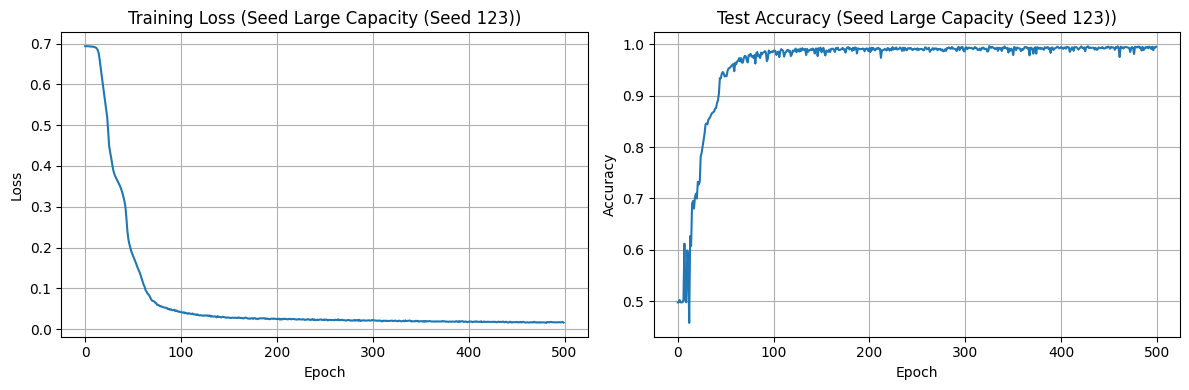

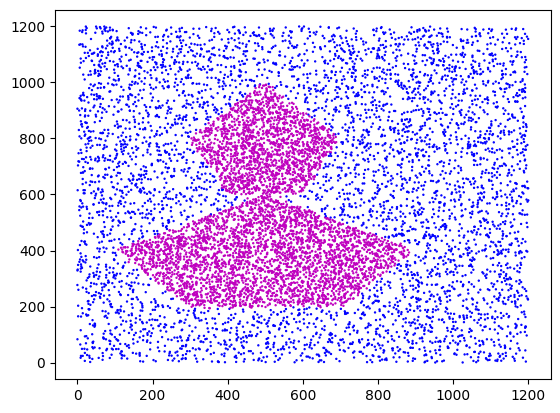


Training with seed 456
Epoch [0/500], Loss: 0.6941, Test Acc: 0.4977
Epoch [50/500], Loss: 0.1746, Test Acc: 0.9474
Epoch [100/500], Loss: 0.0401, Test Acc: 0.9898
Epoch [150/500], Loss: 0.0289, Test Acc: 0.9910
Epoch [200/500], Loss: 0.0253, Test Acc: 0.9814
Epoch [250/500], Loss: 0.0229, Test Acc: 0.9945
Epoch [300/500], Loss: 0.0201, Test Acc: 0.9817
Epoch [350/500], Loss: 0.0196, Test Acc: 0.9945
Epoch [400/500], Loss: 0.0184, Test Acc: 0.9957
Epoch [450/500], Loss: 0.0177, Test Acc: 0.9908
Final Train Accuracy: 0.9949
Final Test Accuracy: 0.9954


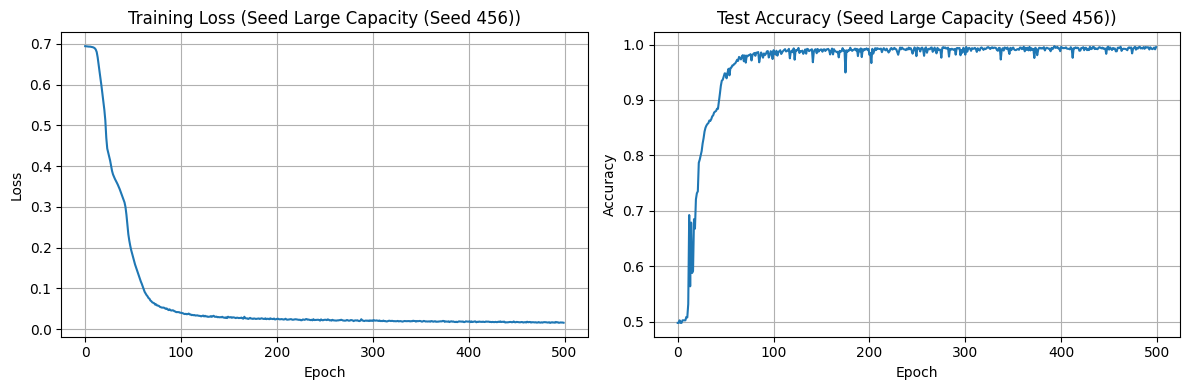

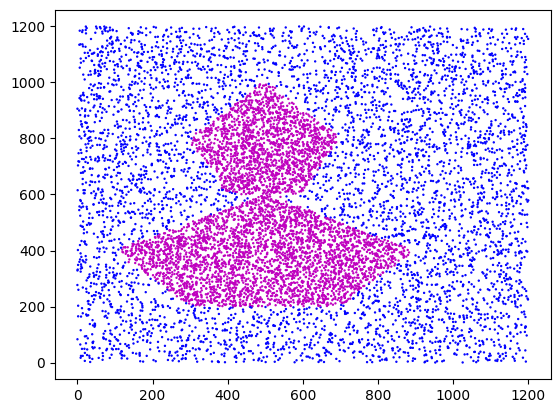


Training with seed 789
Epoch [0/500], Loss: 0.6936, Test Acc: 0.4977
Epoch [50/500], Loss: 0.1646, Test Acc: 0.9524
Epoch [100/500], Loss: 0.0405, Test Acc: 0.9831
Epoch [150/500], Loss: 0.0271, Test Acc: 0.9889
Epoch [200/500], Loss: 0.0244, Test Acc: 0.9941
Epoch [250/500], Loss: 0.0213, Test Acc: 0.9941
Epoch [300/500], Loss: 0.0194, Test Acc: 0.9947
Epoch [350/500], Loss: 0.0175, Test Acc: 0.9957
Epoch [400/500], Loss: 0.0174, Test Acc: 0.9911
Epoch [450/500], Loss: 0.0166, Test Acc: 0.9727
Final Train Accuracy: 0.9943
Final Test Accuracy: 0.9942


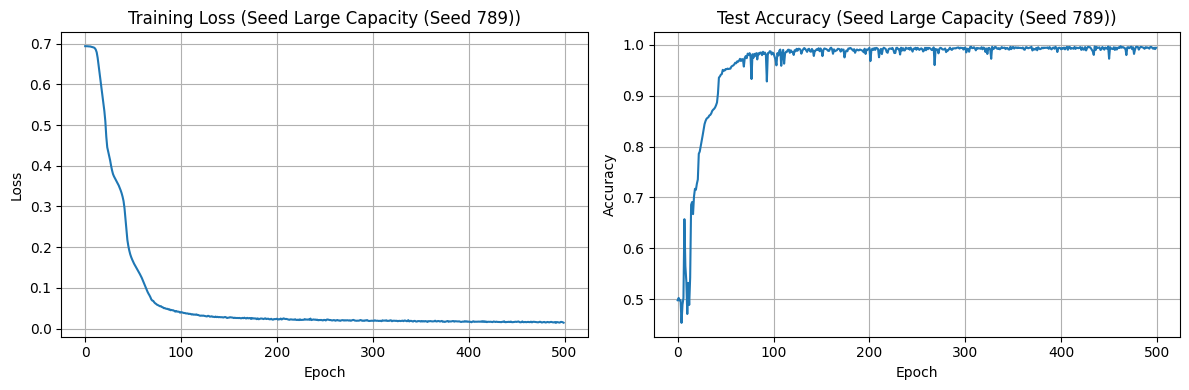

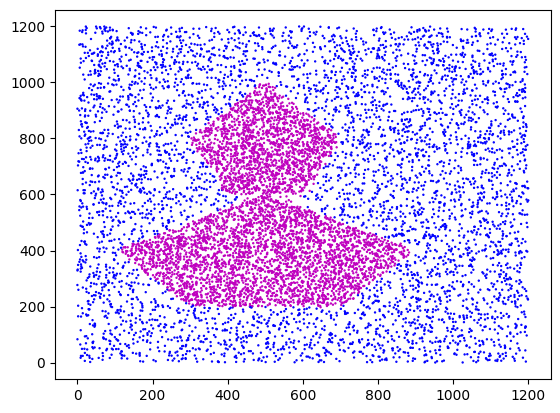


Training with seed 999
Epoch [0/500], Loss: 0.6941, Test Acc: 0.5023


In [ ]:
# Hyperparameters
batch_size = 128
learning_rate = 0.1
epochs = 500
seeds = [7, 123, 456, 789, 999]

# Define different architectures to test
architectures = {
    "Increased Width": [128, 64],  # Wider but same depth
    "Increased Depth": [32, 16, 8, 4],  # Deeper but similar total capacity
    "Large Capacity": [256, 128, 64, 32],  # Both wider and deeper
}

results = {}

for arch_name, hidden_dims in architectures.items():
    print(f"Testing Architecture: {arch_name}")
    print(f"Hidden Dimensions: {hidden_dims}")

    train_accuracies = []
    test_accuracies = []

    for i, seed in enumerate(seeds):
        print(f"\nTraining with seed {seed}")
        set_seed(seed)

        # Create model and dataloaders
        model = FlexibleMLP(input_dim=2, hidden_dims=hidden_dims, output_dim=1)
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

        # Train model
        train_losses, test_accs = train_model(model, train_loader, test_loader, epochs, learning_rate)

        # Final evaluation
        train_acc = evaluate_model(model, train_data_tensor, train_labels_tensor)
        test_acc = evaluate_model(model, test_data_tensor, test_labels_tensor)

        train_accuracies.append(train_acc)
        test_accuracies.append(test_acc)

        print(f"Final Train Accuracy: {train_acc:.4f}")
        print(f"Final Test Accuracy: {test_acc:.4f}")

        # Plot training curves and visualize predictions
        plot_results(train_losses, test_accs, f"{arch_name} (Seed {seed})")
        model.eval()
        with torch.no_grad():
            # Get predictions for test set (last 10000 points)
            test_predictions = model(test_data_tensor)
            test_predictions = (test_predictions > 0.5).float().numpy().flatten()
        visualize_datapoints(X[50000:], test_predictions)

    # Store results
    results[arch_name] = {
        'train_mean': np.mean(train_accuracies),
        'train_std': np.std(train_accuracies),
        'test_mean': np.mean(test_accuracies),
        'test_std': np.std(test_accuracies),
        'train_accuracies': train_accuracies,
        'test_accuracies': test_accuracies
    }

    # Print summary for this architecture
    print(f"\n{arch_name} Summary:")
    print(f"Train Accuracies: {[f'{acc:.4f}' for acc in train_accuracies]}")
    print(f"Test Accuracies: {[f'{acc:.4f}' for acc in test_accuracies]}")
    print(f"Mean Train Accuracy: {results[arch_name]['train_mean']:.4f} ± {results[arch_name]['train_std']:.4f}")
    print(f"Mean Test Accuracy: {results[arch_name]['test_mean']:.4f} ± {results[arch_name]['test_std']:.4f}")

Testing Architecture: Large Capacity
Hidden Dimensions: [256, 128, 64, 32]

Training with seed 999
Epoch [0/500], Loss: 0.6941, Test Acc: 0.5023
Epoch [50/500], Loss: 0.2903, Test Acc: 0.8910
Epoch [100/500], Loss: 0.0441, Test Acc: 0.9873
Epoch [150/500], Loss: 0.0286, Test Acc: 0.9903
Epoch [200/500], Loss: 0.0264, Test Acc: 0.9860
Epoch [250/500], Loss: 0.0228, Test Acc: 0.9911
Epoch [300/500], Loss: 0.0206, Test Acc: 0.9925
Epoch [350/500], Loss: 0.0201, Test Acc: 0.9912
Epoch [400/500], Loss: 0.0183, Test Acc: 0.9912
Epoch [450/500], Loss: 0.0177, Test Acc: 0.9907
Final Train Accuracy: 0.9939
Final Test Accuracy: 0.9945


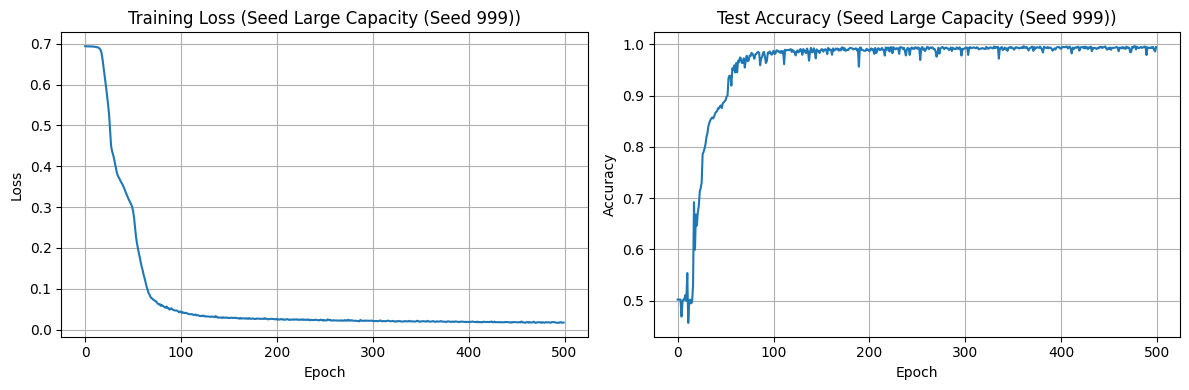

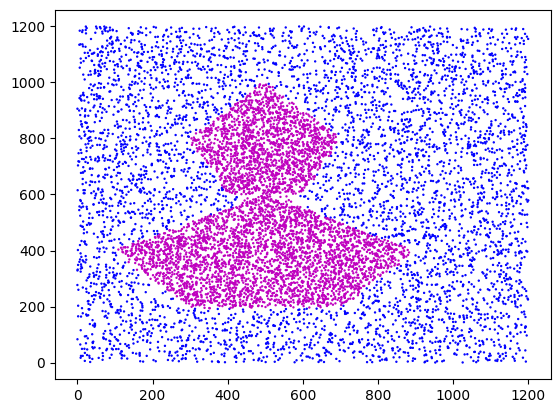


Large Capacity Summary:
Train Accuracies: ['0.9939']
Test Accuracies: ['0.9945']
Mean Train Accuracy: 0.9939 ± 0.0000
Mean Test Accuracy: 0.9945 ± 0.0000


In [ ]:
# Increase width and depth, seed 999, rerun because previous cell disconnected

# Hyperparameters
batch_size = 128
learning_rate = 0.1
epochs = 500
seeds = [999]

# Define different architectures to test
architectures = {
    "Large Capacity": [256, 128, 64, 32],  # Both wider and deeper
}

results = {}

for arch_name, hidden_dims in architectures.items():
    print(f"Testing Architecture: {arch_name}")
    print(f"Hidden Dimensions: {hidden_dims}")

    train_accuracies = []
    test_accuracies = []

    for i, seed in enumerate(seeds):
        print(f"\nTraining with seed {seed}")
        set_seed(seed)

        # Create model and dataloaders
        model = FlexibleMLP(input_dim=2, hidden_dims=hidden_dims, output_dim=1)
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

        # Train model
        train_losses, test_accs = train_model(model, train_loader, test_loader, epochs, learning_rate)

        # Final evaluation
        train_acc = evaluate_model(model, train_data_tensor, train_labels_tensor)
        test_acc = evaluate_model(model, test_data_tensor, test_labels_tensor)

        train_accuracies.append(train_acc)
        test_accuracies.append(test_acc)

        print(f"Final Train Accuracy: {train_acc:.4f}")
        print(f"Final Test Accuracy: {test_acc:.4f}")

        # Plot training curves and visualize predictions
        plot_results(train_losses, test_accs, f"{arch_name} (Seed {seed})")
        model.eval()
        with torch.no_grad():
            # Get predictions for test set (last 10000 points)
            test_predictions = model(test_data_tensor)
            test_predictions = (test_predictions > 0.5).float().numpy().flatten()
        visualize_datapoints(X[50000:], test_predictions)

    # Store results
    results[arch_name] = {
        'train_mean': np.mean(train_accuracies),
        'train_std': np.std(train_accuracies),
        'test_mean': np.mean(test_accuracies),
        'test_std': np.std(test_accuracies),
        'train_accuracies': train_accuracies,
        'test_accuracies': test_accuracies
    }

    # Print summary for this architecture
    print(f"\n{arch_name} Summary:")
    print(f"Train Accuracies: {[f'{acc:.4f}' for acc in train_accuracies]}")
    print(f"Test Accuracies: {[f'{acc:.4f}' for acc in test_accuracies]}")
    print(f"Mean Train Accuracy: {results[arch_name]['train_mean']:.4f} ± {results[arch_name]['train_std']:.4f}")
    print(f"Mean Test Accuracy: {results[arch_name]['test_mean']:.4f} ± {results[arch_name]['test_std']:.4f}")

In [ ]:
# Only for architecture (both wider and deeper) because previous run cell terminated

train_accuracies = ['0.9927', '0.9947', '0.9949', '0.9943', '0.9939']
test_accuracies = ['0.9932', '0.9954', '0.9954', '0.9942', '0.9945']

train_accuracies_float = [float(acc) for acc in train_accuracies]
test_accuracies_float = [float(acc) for acc in test_accuracies]

train_mean = np.mean(train_accuracies_float)
train_std = np.std(train_accuracies_float)
test_mean = np.mean(test_accuracies_float)
test_std = np.std(test_accuracies_float)

print(f"Mean Train Accuracy: {train_mean:.4f} ± {train_std:.4f}")
print(f"Mean Test Accuracy: {test_mean:.4f} ± {test_std:.4f}")

Mean Train Accuracy: 0.9941 ± 0.0008
Mean Test Accuracy: 0.9945 ± 0.0008


## Problem 2

All code for Problem 2 should go below. We provide data loaders and relevant imports to get you started. If you are working locally (instead of using Google Colab), we recommend using Conda to install pytorch (https://pytorch.org).

### Imports

In [2]:
## Additional External Libraries (Deep Learning)
import torch
import torch.nn as nn
from torch.autograd import Variable
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as tfs
from PIL import Image
from torchvision.datasets import FashionMNIST
from torch.utils.data import SubsetRandomSampler

### Data Loading

In [3]:
# Hyperparameter (Feel Free to Change These, but Make Sure your Training Loop Still Works as Expected)
TRAIN_BATCH_SIZE = 50
VAL_BATCH_SIZE = 50
TEST_BATCH_SIZE = 1

# Transform data to PIL images
transforms = tfs.Compose([tfs.ToTensor()])

# Train/Val Subsets
train_mask = range(50000)
val_mask = range(50000, 60000)

# Download/Load Dataset
train_dataset = FashionMNIST('./data', train=True, transform=transforms, download=True)
test_dataset = FashionMNIST('./data', train=False, transform=transforms, download=True)

# Data Loaders
train_dataloader = DataLoader(train_dataset, batch_size=TRAIN_BATCH_SIZE, sampler=SubsetRandomSampler(train_mask))
val_dataloader = DataLoader(train_dataset, batch_size=VAL_BATCH_SIZE, sampler=SubsetRandomSampler(val_mask))
test_dataloader = DataLoader(test_dataset, batch_size=TEST_BATCH_SIZE)

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 211kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.93MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.4MB/s]


## Problem 2a)

### Design Model

In [4]:
class CNNet(nn.Module):
    """
    CNN with only conv, pooling, and activation layers
    Designed for 1-channel grayscale images
    """

    def __init__(self, num_classes=10, input_channels=1):
        super(CNNet, self).__init__()

        self.features = nn.Sequential(
            # Block 1: Conv -> ReLU -> Pool
            nn.Conv2d(input_channels, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 2: Conv -> ReLU -> Pool
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 3: Conv -> ReLU -> Pool
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        # For 28x28 input: 28 -> 14 -> 7 -> 3
        self.classifier = nn.Sequential(
            nn.Linear(128 * 3 * 3, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

### Model Training

In [5]:
def train(model,
          optimizer,
          loss_f,
          lr,
          epochs=50,
          train_dataloader=train_dataloader,
          val_dataloader=val_dataloader,
          test_dataloader=test_dataloader,
          **kwargs):
    """
    Training loop for CNN model
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    print(f"Using device: {device}")

    train_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):
        # Training
        model.train()
        running_loss = 0.0
        train_correct = 0
        train_total = 0

        for batch_idx, (data, targets) in enumerate(train_dataloader):
            data, targets = data.to(device), targets.to(device)

            if len(data.shape) == 3:
                data = data.unsqueeze(1)

            optimizer.zero_grad()
            outputs = model(data)
            loss = loss_f(outputs, targets)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            # Calculate training accuracy for this batch
            _, predicted = torch.max(outputs.data, 1)
            train_total += targets.size(0)
            train_correct += (predicted == targets).sum().item()

        avg_train_loss = running_loss / len(train_dataloader)
        train_losses.append(avg_train_loss)

        train_accuracy = 100 * train_correct / train_total
        train_accuracies.append(train_accuracy)

        # Validation
        model.eval()
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for data, targets in val_dataloader:
                data, targets = data.to(device), targets.to(device)

                # Ensure data has the right shape
                if len(data.shape) == 3:
                    data = data.unsqueeze(1)

                outputs = model(data)
                _, predicted = torch.max(outputs.data, 1)
                val_total += targets.size(0)
                val_correct += (predicted == targets).sum().item()

        val_accuracy = 100 * val_correct / val_total
        val_accuracies.append(val_accuracy)

        print(f'Epoch {epoch+1}/{epochs}: '
              f'Train Loss: {avg_train_loss:.4f}, '
              f'Train Accuracy: {train_accuracy:.2f}%, '
              f'Val Accuracy: {val_accuracy:.2f}%')

    # Test evaluation
    model.eval()
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for data, targets in test_dataloader:
            data, targets = data.to(device), targets.to(device)

            if len(data.shape) == 3:
                data = data.unsqueeze(1)

            outputs = model(data)
            _, predicted = torch.max(outputs.data, 1)
            test_total += targets.size(0)
            test_correct += (predicted == targets).sum().item()

    test_accuracy = 100 * test_correct / test_total
    print(f'Final Test Accuracy: {test_accuracy:.2f}%')

    return model, train_losses, train_accuracies, val_accuracies, test_accuracy

In [6]:
import torch.optim as optim

## Hyperparameters
EPOCH = 50
LR = 0.01

## Setting up the model, optimizer, and loss function
model = CNNet()
optimizer = optim.SGD(model.parameters(), lr=LR)
loss_f = nn.CrossEntropyLoss()

In [7]:
## Run Training Loop
out = train(model, optimizer, loss_f, LR)

Using device: cuda
Epoch 1/50: Train Loss: 1.7549, Train Accuracy: 36.48%, Val Accuracy: 67.58%
Epoch 2/50: Train Loss: 0.7549, Train Accuracy: 71.62%, Val Accuracy: 71.21%
Epoch 3/50: Train Loss: 0.6415, Train Accuracy: 76.11%, Val Accuracy: 76.91%
Epoch 4/50: Train Loss: 0.5700, Train Accuracy: 78.74%, Val Accuracy: 79.11%
Epoch 5/50: Train Loss: 0.5099, Train Accuracy: 81.05%, Val Accuracy: 80.52%
Epoch 6/50: Train Loss: 0.4697, Train Accuracy: 82.80%, Val Accuracy: 80.97%
Epoch 7/50: Train Loss: 0.4369, Train Accuracy: 83.94%, Val Accuracy: 83.74%
Epoch 8/50: Train Loss: 0.4122, Train Accuracy: 85.06%, Val Accuracy: 85.25%
Epoch 9/50: Train Loss: 0.3893, Train Accuracy: 85.70%, Val Accuracy: 85.04%
Epoch 10/50: Train Loss: 0.3707, Train Accuracy: 86.37%, Val Accuracy: 84.32%
Epoch 11/50: Train Loss: 0.3571, Train Accuracy: 86.79%, Val Accuracy: 86.38%
Epoch 12/50: Train Loss: 0.3428, Train Accuracy: 87.64%, Val Accuracy: 86.73%
Epoch 13/50: Train Loss: 0.3304, Train Accuracy: 87.90

In [16]:
def plot_results_1(train_losses, val_acc):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(train_losses)
    ax1.set_title(f'Training Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.grid(True)

    ax2.plot(val_acc)
    ax2.set_title(f'Validation Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

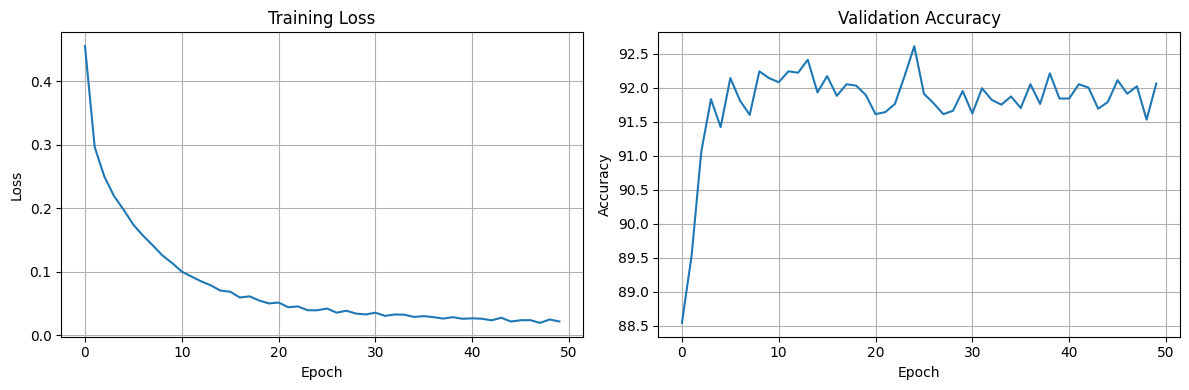

In [19]:
plot_results_1(out[1], out[3])

## Problem 2b)

Now try to improve your model using additional techniques learned during class. You should be able to use the same training function as above, but will need to create a new model architecture.

### Data Loading

You should maintain the splits from above, but feel free to alter the dataloaders (i.e. transforms) as you wish.

In [ ]:
# Hyperparameter (Feel Free to Change These, but Make Sure your Training Loop Still Works as Expected)
TRAIN_BATCH_SIZE = 50
VAL_BATCH_SIZE = 50
TEST_BATCH_SIZE = 1

# Transform data to PIL images
transforms = tfs.Compose([tfs.ToTensor()]) ##TODO: Use the same from above or consider alternatives

# Train/Val Subsets
train_mask = range(50000)
val_mask = range(50000, 60000)

# Download/Load Dataset
train_dataset = FashionMNIST('./data', train=True, transform=transforms, download=True)
test_dataset = FashionMNIST('./data', train=False, transform=transforms, download=True)

# Data Loaders
train_dataloader = DataLoader(train_dataset, batch_size=TRAIN_BATCH_SIZE, sampler=SubsetRandomSampler(train_mask))
val_dataloader = DataLoader(train_dataset, batch_size=VAL_BATCH_SIZE, sampler=SubsetRandomSampler(val_mask))
test_dataloader = DataLoader(test_dataset, batch_size=TEST_BATCH_SIZE)

### Model Design

In [10]:
##TODO: Try to improve upon your previous architecture
class NormCNNet(nn.Module):
    """
    Convolutional Neural Network for image classification
    Updated for 1-channel grayscale images (e.g., MNIST-like data)
    """

    def __init__(self, num_classes=10, input_channels=1):
        """
        Initialize CNN layers for 1-channel input
        """
        super(NormCNNet, self).__init__()

        # First convolutional block
        self.conv1 = nn.Conv2d(in_channels=input_channels, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU(inplace=True)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Second convolutional block
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU(inplace=True)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Third convolutional block
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.relu3 = nn.ReLU(inplace=True)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Calculate the size after convolutions and pooling
        # For input size 28x28: 28 -> 14 -> 7 -> 3 (after 3 pooling layers)
        self.fc_input_size = 128 * 3 * 3

        # Fully connected layers
        self.fc1 = nn.Linear(self.fc_input_size, 256)
        self.relu4 = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, num_classes)

        # Initialize weights
        self._initialize_weights()

    def _initialize_weights(self):
        """
        Initialize weights using Kaiming initialization
        """
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        """
        Forward pass of the CNN
        x: input tensor of shape (batch_size, 1, 28, 28) for grayscale images
        """
        # First block
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        # Second block
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        # Third block
        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu3(x)
        x = self.pool3(x)

        # Flatten
        x = x.view(x.size(0), -1)

        # Fully connected layers
        x = self.fc1(x)
        x = self.relu4(x)
        x = self.dropout(x)
        x = self.fc2(x)

        return x

### Model Training

In [13]:
##TODO: Fit and evaluate your model. What do you observe?
model = NormCNNet()
LR = 0.001
optimizer = optim.Adam(model.parameters(), lr=LR)
loss_f = nn.CrossEntropyLoss()

In [14]:
## Run Training Loop
out = train(model, optimizer, loss_f, LR)

Using device: cuda
Epoch 1/50: Train Loss: 0.4557, Train Accuracy: 83.51%, Val Accuracy: 88.54%
Epoch 2/50: Train Loss: 0.2967, Train Accuracy: 89.20%, Val Accuracy: 89.53%
Epoch 3/50: Train Loss: 0.2500, Train Accuracy: 90.89%, Val Accuracy: 91.06%
Epoch 4/50: Train Loss: 0.2193, Train Accuracy: 91.98%, Val Accuracy: 91.83%
Epoch 5/50: Train Loss: 0.1975, Train Accuracy: 92.77%, Val Accuracy: 91.42%
Epoch 6/50: Train Loss: 0.1740, Train Accuracy: 93.60%, Val Accuracy: 92.14%
Epoch 7/50: Train Loss: 0.1568, Train Accuracy: 94.26%, Val Accuracy: 91.81%
Epoch 8/50: Train Loss: 0.1416, Train Accuracy: 94.76%, Val Accuracy: 91.60%
Epoch 9/50: Train Loss: 0.1256, Train Accuracy: 95.42%, Val Accuracy: 92.24%
Epoch 10/50: Train Loss: 0.1136, Train Accuracy: 95.90%, Val Accuracy: 92.14%
Epoch 11/50: Train Loss: 0.1002, Train Accuracy: 96.29%, Val Accuracy: 92.08%
Epoch 12/50: Train Loss: 0.0924, Train Accuracy: 96.51%, Val Accuracy: 92.24%
Epoch 13/50: Train Loss: 0.0848, Train Accuracy: 96.83

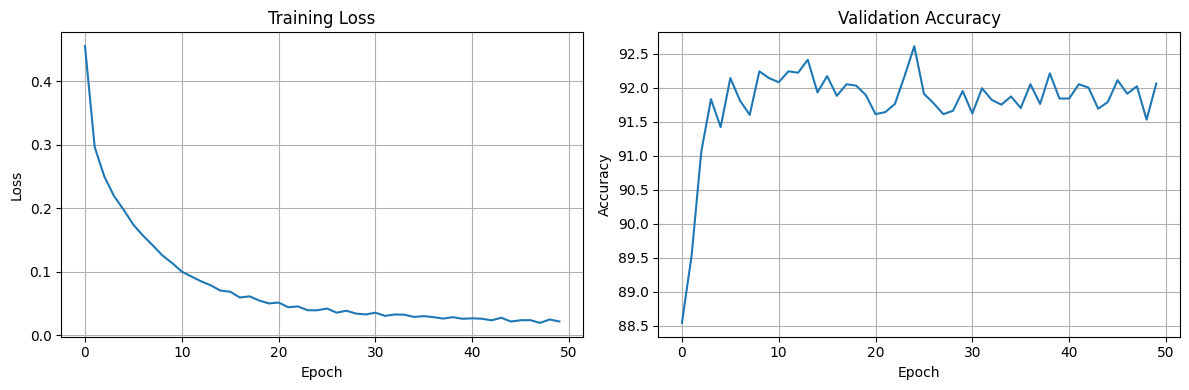

In [20]:
plot_results_1(out[1], out[3])

## Problem 2c)

Write down your response in the final report.